In [3]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

# CSV 파일 불러오기 + 데이터 확인 (컬럼명, 레이블 수)

In [153]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/5week/diabetes.csv")

# 데이터 확인
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [154]:
# 컬럼명 확인
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Text(0.5, 1.0, 'Outcome')

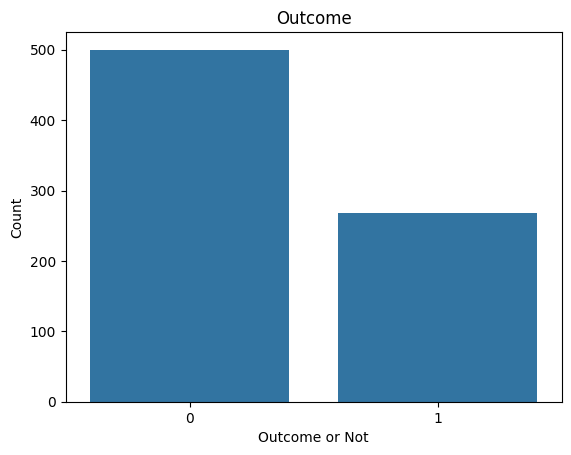

In [155]:
# 레이블 갯수 확인 (그래프)
sns.countplot(data = df, x="Outcome")
plt.xlabel("Outcome or Not")
plt.ylabel("Count")
plt.title("Outcome")

In [156]:
# 레이블 갯수 확인 (숫자)
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


# 결측치 확인 및 제거

In [157]:
# 결측치 확인
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [200]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# 1. 0을 NaN으로 바꾸기
df[cols] = df[cols].replace(0, np.nan)

# 2. 중앙값으로 채우기
for col in cols:
    df[col] = df[col].fillna(df[col].median())

# 결측치 제거
df = df.dropna()
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# 데이터 분포 확인 (컬럼별 히스토그램, 산점도)
- 모델 학습 전, 한 컬럼이 어떤 값들이 어떻게 퍼져있는지 보는 것
  - 데이터 분표 형태 : 학습에 적합한 분포인지
  - 이상치 존재 여부 : 극단값이 있는지
  - 스케일 차이 : 정규화가 필요한지
  - 변수의 유효성 판단 : 학습에 도움되는 특징인지

/tmp/ipykernel_12980/531335707.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Glucose'], kde = True, hist = False, ax=ax1)
/tmp/ipykernel_12980/531335707.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['BMI'], ax=ax2)


<Axes: xlabel='BMI', ylabel='Density'>

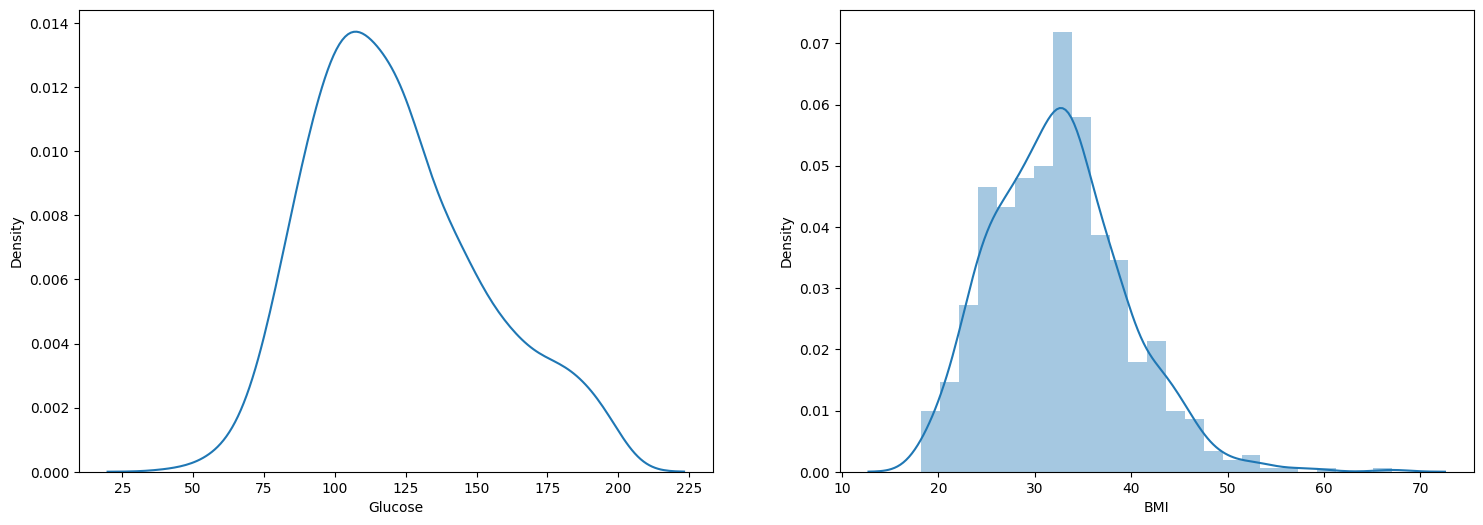

In [201]:
# 컬럼별 히스토그램 확인
# 'Glucose'와'BMI' 칼럼 선택

figure = plt.figure(figsize=(18,6))

ax1 = plt.subplot(1,2,1)
sns.distplot(df['Glucose'], kde = True, hist = False, ax=ax1)

ax2 = plt.subplot(1,2,2)
sns.distplot(df['BMI'], ax=ax2)

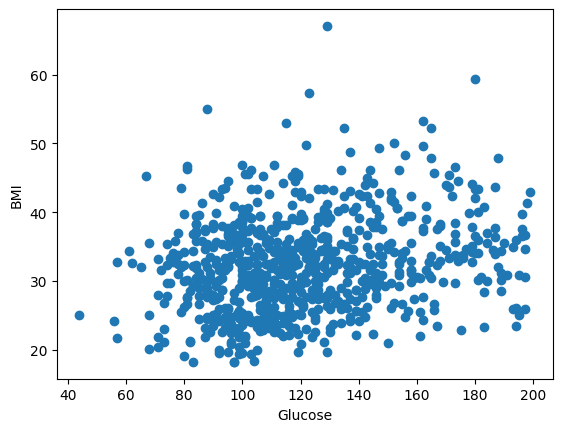

In [202]:
# 산점도 확인

plt.scatter(df['Glucose'], df['BMI'])
plt.xlabel('Glucose')
plt.ylabel('BMI')

plt.show()

# X / y 설정

In [203]:
X=df.drop('Outcome',axis=1)
X.head()

y=df['Outcome']
y.value_counts()

# 데이터의 처음 5개 행 출력 (default = 5)
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


# 원-핫 인코딩
- 범주형(label)을 모델이 이해할 수 있는 숫자(벡터) 형태로 바꾸는 것

In [204]:
# pd.get_dummies(y) : label을 원-핫 형태로 변환
# .values : pandas → numpy 배열로 변환

# Y = pd.get_dummies(y).values

# train / test 데이터 분할

In [231]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

# 정규화 StandardScaler

In [232]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP(Dense) 모델 생성
- 입력 데이터의 여러 특성을 받아, 클래스(label)를 분류하는 신경망 모델

In [233]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [234]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

# 빈 신경망 모델 생성
model = Sequential()

# 은닉층 생성 : Dense(뉴런수, 입력특성수, 활성화함수)
model.add(Dense(16,input_shape=(8,),activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

# 학습 방법 설정 : compile(학습률, 손실함수, 성능확인방법)
model.compile(Adam(learning_rate=0.0005),'binary_crossentropy',metrics=['accuracy'])

# 모델 구조 출력
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

# 모델 훈련 및 결과 출력
- 학습 데이터를 이용해 신경망을 훈련시키고 > 테스트 데이터에 대한 예측 결과를 만든 뒤 > 그 결과를 최종 클래스 형태로 바꾸는 코드

In [235]:
# 모델 학습
# model_history : 학습 과정 중 기록 저장
# fit(x,y, 전체데이터 30번 반복, 한 번에 16개씩 나눠서, 매 epoch마다 테스트셋으로 성능 확인)
# X_train과 y_train을 보고 가중치를 조금씩 수정하면서 정답을 더 잘 맞추도록 학습
model_history=model.fit(x=X_train, y=y_train, epochs=30, batch_size=16,validation_data= (X_test,y_test))

# 테스트 데이터에 대한 예측값 출력
y_pred = model.predict(X_test)

# 실제값(정답)을 클래스 인덱스로 변환
# y_test_class = np.argmax(y_test,axis=1)

# 예측 확률을 최종 클래스 인덱스로 변환
y_pred_class = (y_pred > 0.5).astype(int).reshape(-1)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6645 - loss: 0.6298 - val_accuracy: 0.7143 - val_loss: 0.5882
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6710 - loss: 0.6077 - val_accuracy: 0.7143 - val_loss: 0.5619
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6775 - loss: 0.5887 - val_accuracy: 0.7273 - val_loss: 0.5358
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6889 - loss: 0.5714 - val_accuracy: 0.7403 - val_loss: 0.5145
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7134 - loss: 0.5561 - val_accuracy: 0.7403 - val_loss: 0.4961
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7362 - loss: 0.5433 - val_accuracy: 0.7468 - val_loss: 0.4794
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7541 - loss: 0.5319 - val_accuracy: 0.7597 - val_loss: 0.4664
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7508 - loss: 0.5228 - val_accuracy: 0.7727 - val_loss:

# Loss(손실값) 변화 그래프
- 노란색: 학습데이터 손실 Training loss
- 빨간색: 검증데이터 손실 Validation loss

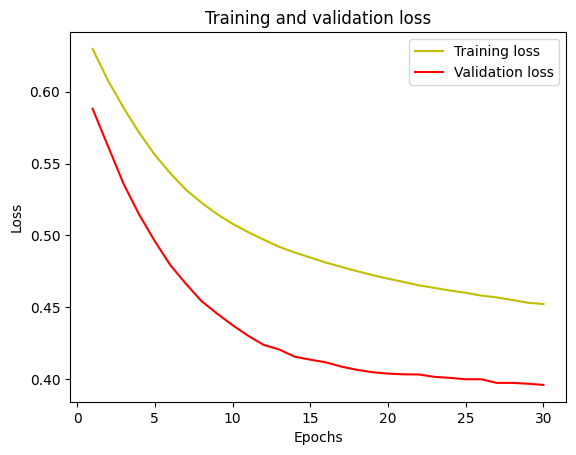

In [236]:
# 학습데이터 손실값 가져오기
loss =model_history.history['loss']
# 검증데이터 손실값 가져오기
val_loss =model_history.history['val_loss']

# epoch 범위 설정 (1~30)
epochs = range(1, len(loss) + 1)

# 그래프 출력
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy(정확도) 변화 그래프
- 노란색: Training accuracy (학습 데이터 정확도)
- 빨간색: Validation accuracy (검증 데이터 정확도)

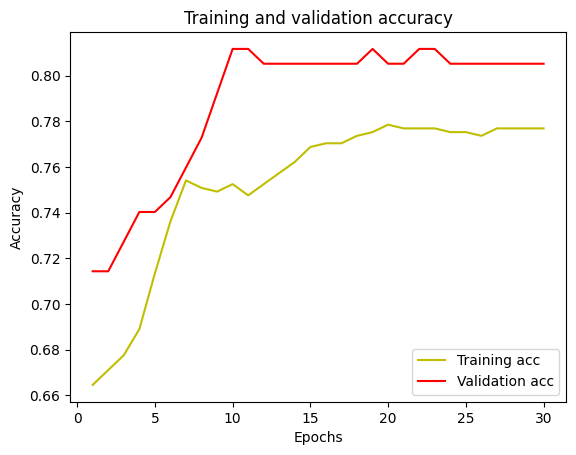

In [237]:
# 학습데이터 정확도
acc =model_history.history['accuracy']
# 검증데이터 정확도
val_acc =model_history.history['val_accuracy']

# 학습데이터 정확도 그래프
plt.plot(epochs, acc, 'y', label='Training acc')
# 검증데이터 정확도 그래프
plt.plot(epochs, val_acc, 'r', label='Validation acc')

# 그래프 그리기
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 모델 성능 평가 Accuracy of the predicted values
- 모델이 얼마나 잘 맞췄는지 구체적으로 분석한 결과
  - precision (정밀도) : 예측값 중 실제 정답은 몇 퍼센트?
  - recall (재현율/민감도) : 실제 정답 중 제대로 예측한 것은 몇 퍼센트?
  - f1 : 균형지표 (precision + recall)
  - accuracy : 최종 정확도

In [238]:
from sklearn.metrics import classification_report,confusion_matrix

# precision, recall, F1-score 출력
print(classification_report(y_test_class,y_pred_class))

# 실제 vs 예측 비교 출력
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86       107
           1       0.67      0.72      0.69        47

    accuracy                           0.81       154
   macro avg       0.77      0.78      0.78       154
weighted avg       0.81      0.81      0.81       154

[[90 17]
 [13 34]]
